In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls, minimize

df = pd.read_csv("data.csv", index_col=0)
df

,PSC,JUNTS,ERC,PP,VOX,COMUNS,CUP,ALIANÇA.CAT,Altres,Cs,Abstenció
1980,0.138185,0.171275,0.054873,0.014556,0.000000,0.115557,0.000000,0.000000,0.117144,0.000000,0.388410
1984,0.193811,0.301318,0.028411,0.049647,0.000000,0.035962,0.000000,0.000000,0.031802,0.000000,0.359048
1988,0.177197,0.272179,0.024616,0.031648,0.000000,0.046166,0.000000,0.000000,0.039541,0.000000,0.408652
1992,0.152089,0.255296,0.043962,0.032968,0.000000,0.035913,0.000000,0.000000,0.025621,0.000000,0.454152
1995,0.159822,0.263467,0.061096,0.084246,0.000000,0.062607,0.000000,0.000000,0.005756,0.000000,0.363006
1999,0.227821,0.226843,0.052261,0.057211,0.000000,0.015129,0.000000,0.000000,0.016845,0.000000,0.403890
2003,0.198586,0.196993,0.104874,0.075627,0.000000,0.046480,0.000000,0.000000,0.008517,0.000000,0.368922
2006,0.153722,0.180767,0.080571,0.060980,0.000000,0.054760,0.000000,0.000000,0.013357,0.017425,0.438418
2010,0.111491,0.234199,0.042640,0.075148,0.000000,0.044927,0.000000,0.000000,0.061473,0.020696,0.409426
2012,0.101217,0.215104,0.095984,0.091014,0.000000,0.069380,0.024398,0.000000,0.040548,0.053099,0.309256


In [2]:
list(df.columns)

['PSC',
 'JUNTS',
 'ERC',
 'PP',
 'VOX',
 'COMUNS',
 'CUP',
 'ALIANÇA.CAT',
 'Altres',
 'Cs',
 'Abstenció']

Model ajustat correctament amb pesos temporals (Decay Rate: 0.01)
Pesos aplicats per pas (de més antic a més recent): [0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01 1.02 1.03 1.04 1.05 1.06]
Model de Cadena de Markov Estable (14 Anys, 11 Partits)
Matriu de Transició Global (Files = Destí, Columnes = Origen):
                PSC   JUNTS     ERC      PP     VOX  COMUNS     CUP  ALIANÇA.CAT  Altres      Cs  Abstenció
PSC          0.7808  0.0053  0.0033  0.0025  0.0095  0.0757  0.0080          0.0  0.0418  0.0004     0.0695
JUNTS        0.0027  0.5937  0.0000  0.0000  0.0000  0.0735  0.0000          0.0  0.1546  0.0000     0.1984
ERC          0.0000  0.1129  0.6185  0.0371  0.0000  0.0000  0.0018          0.0  0.0040  0.0011     0.0051
PP           0.0003  0.0000  0.0000  0.8204  0.0065  0.0000  0.0000          0.0  0.0024  0.0000     0.0405
VOX          0.0000  0.0000  0.0013  0.0003  0.9839  0.0028  0.0002          0.0  0.0000  0.0020     0.0120
COMUNS       0.0033  0.0020  0.0000  0.0029  0.0

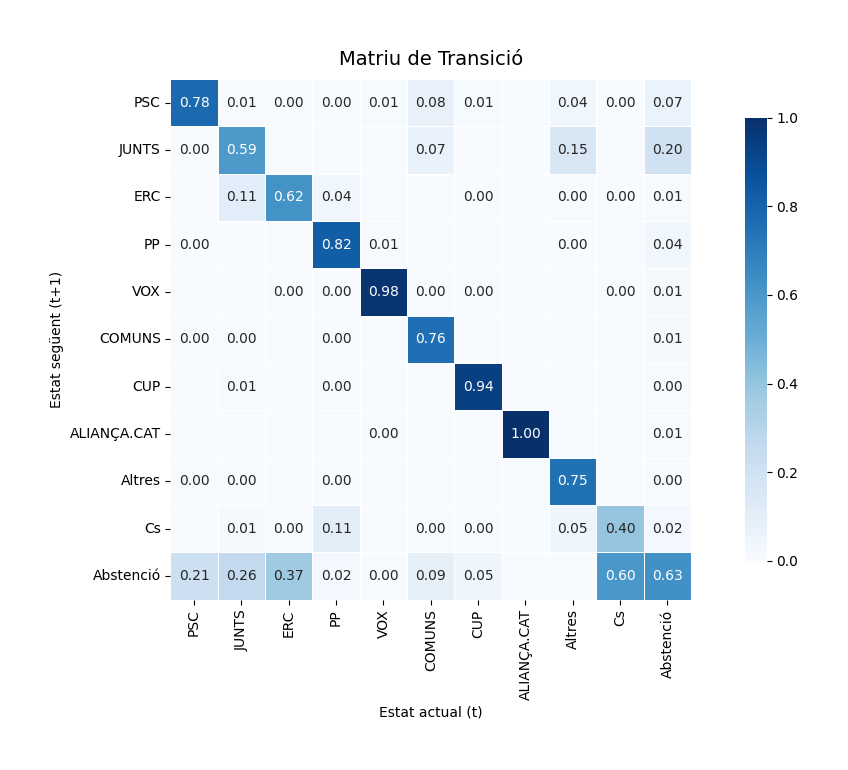

In [3]:
from utils import StableMarkovChain

mc = StableMarkovChain(df)
mc.fit(decay_rate=0.01,sparse_threshold=1e-9,fidelitat_threshold=0)

print(mc)
mc.plot_transition_matrix()

La matriu és reductible. Calculant comportament a llarg termini...
PSC            0.022797
JUNTS          0.028414
ERC            0.010694
PP             0.014618
VOX            0.049145
COMUNS         0.003765
CUP            0.009947
ALIANÇA.CAT    0.798704
Altres         0.000096
Cs             0.005619
Abstenció      0.056200
dtype: float64


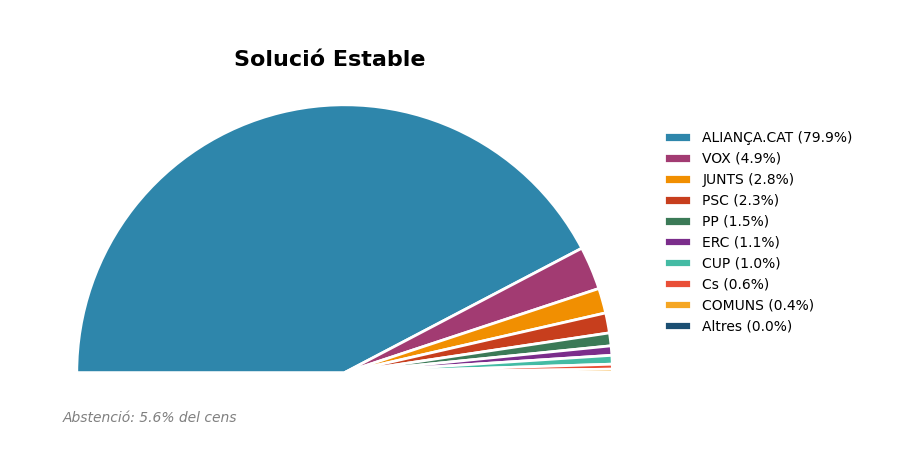

In [4]:
print(mc.get_steady_state())
mc.plot_steady_state('steady_state_basic.png')

In [5]:
"""import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(df_P_final)

# Trobar l'índex de l'autovalor més proper a 1
idx = np.argmin(np.abs(eigenvalues - 1))

# Extreure el vector i normalitzar (suma = 1)
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

partits = list(df_P_final.columns)
for p, v in zip(partits, pi):
    print(f"{p:10s}: {v:.4f}")

###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######
print("\nComprovació de la distribució estacionària:")
print(np.allclose(df_P_final @ pi, pi))  # Ha de donar True
print(pi.sum())                    # Ha de donar 1.0"""

'import numpy as np\n\neigenvalues, eigenvectors = np.linalg.eig(df_P_final)\n\n# Trobar l\'índex de l\'autovalor més proper a 1\nidx = np.argmin(np.abs(eigenvalues - 1))\n\n# Extreure el vector i normalitzar (suma = 1)\npi = np.real(eigenvectors[:, idx])\npi = pi / pi.sum()\n\npartits = list(df_P_final.columns)\nfor p, v in zip(partits, pi):\n    print(f"{p:10s}: {v:.4f}")\n\n###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######\nprint("\nComprovació de la distribució estacionària:")\nprint(np.allclose(df_P_final @ pi, pi))  # Ha de donar True\nprint(pi.sum())                    # Ha de donar 1.0'

Per al Teorema de Perron-Frobenius, una cadena de Markov irreductible i aperiòdica sempre té una única distribució estacionària π > 0.

In [6]:
mc.verify_steady_state()

VERIFICACIÓ DE L'EXISTÈNCIA DE LA DISTR. ESTACIONÀRIA

1. Matriu estocàstica (columnes sumen 1):
   · Sumes de cada columna: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
   · Columnes sumen 1:      True
   · Valors no negatius:    True

2. Irreductibilitat (tots els estats es comuniquen): False

No és irreductible. ÉS REDUCTIBLE → No es pot garantir una distribució estacionària única.


False

In [7]:
mc.export_for_flourish("election_flows_basic.csv")

[OK] Flourish file saved: election_flows_basic.csv


,target,source,value
0,PSC,PSC,0.121063
1,PSC,JUNTS,0.000634
2,PSC,ERC,0.000249
3,PSC,PP,0.000150
4,PSC,VOX,0.000417
...,...,...,...
112,Abstenció,ERC,0.028380
113,Abstenció,PP,0.001388
115,Abstenció,COMUNS,0.002890
116,Abstenció,CUP,0.001060


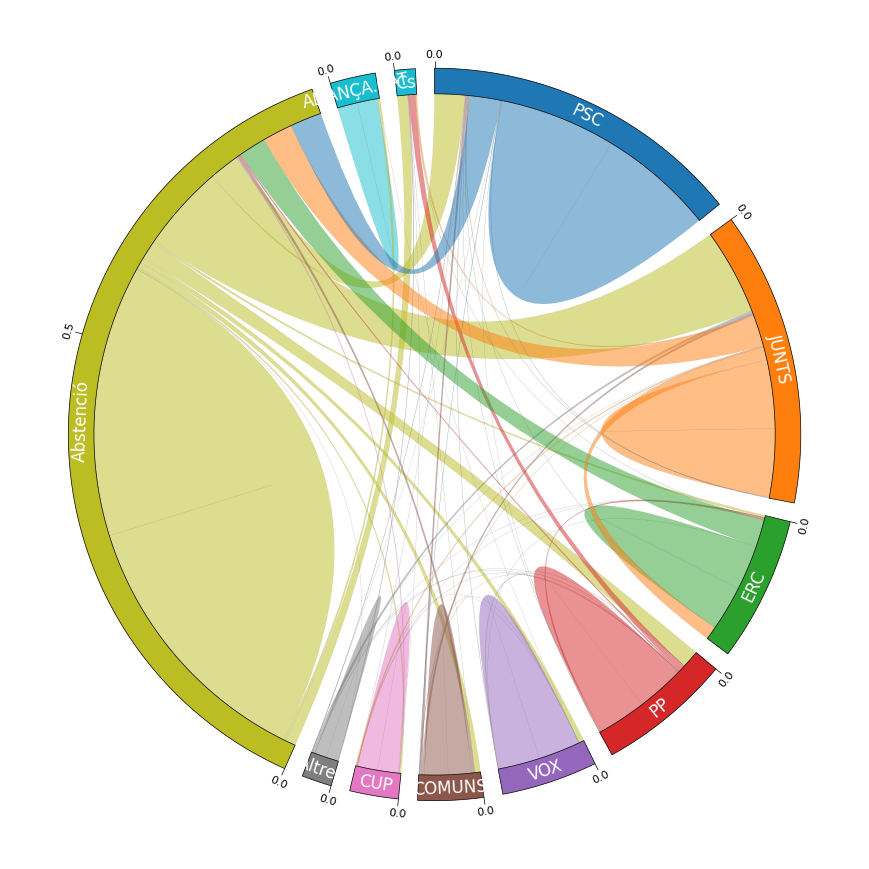

In [8]:
mc.plot_chord()

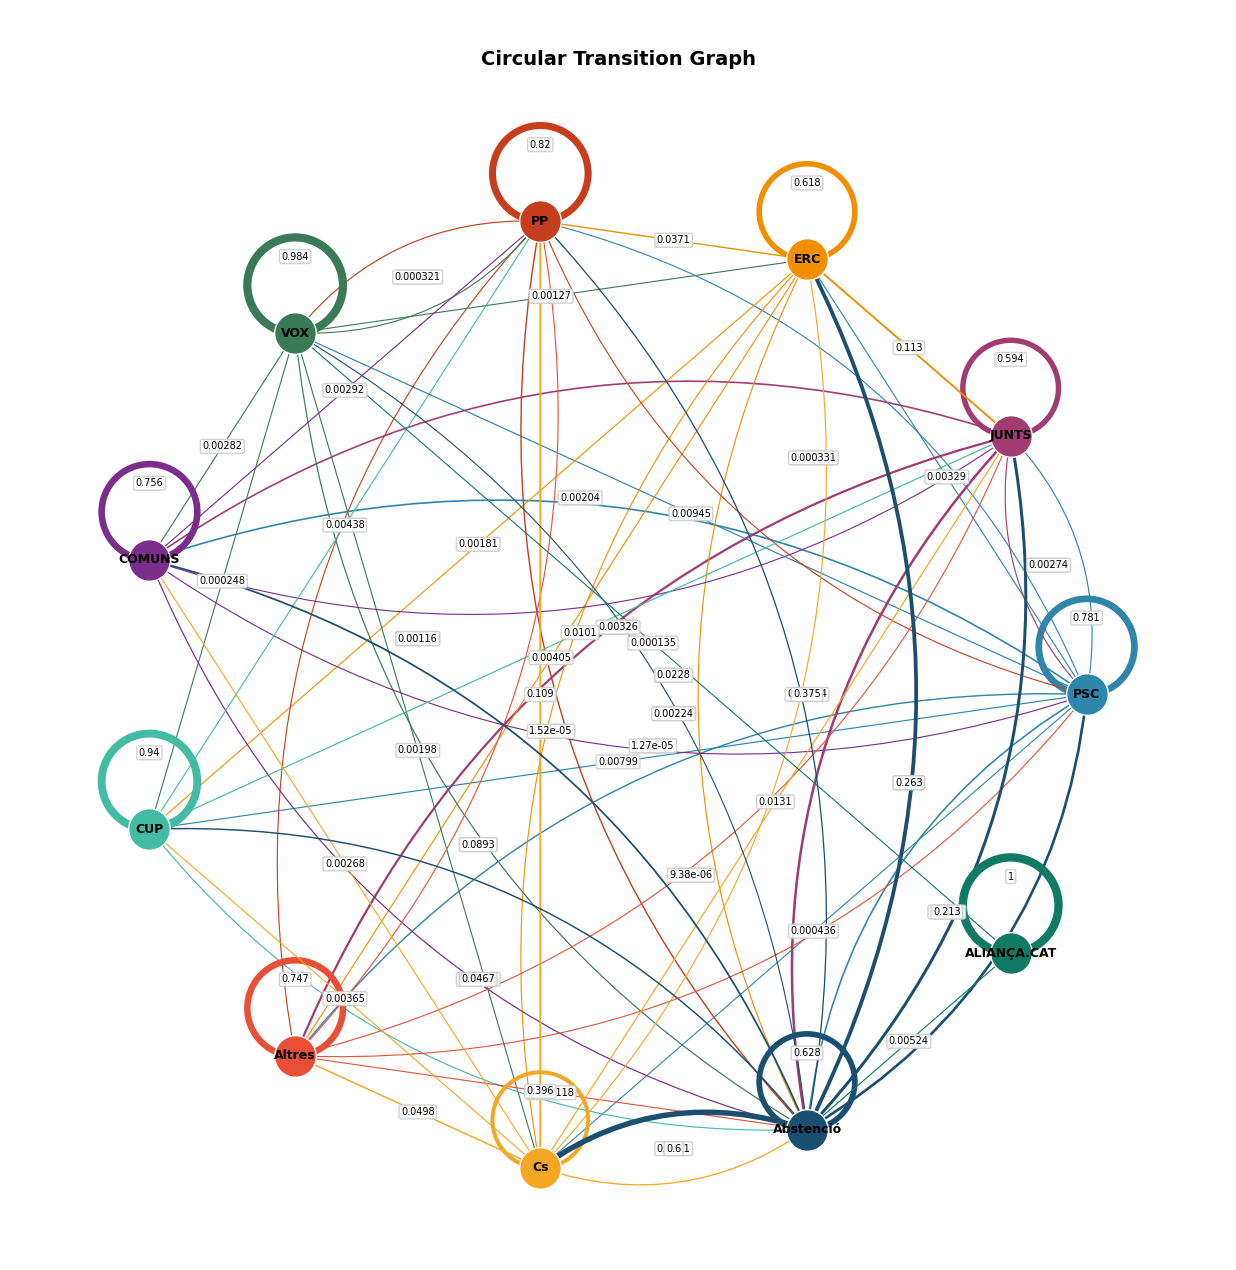

In [9]:
mc.plot_graph()

### Efecte d'una campanya
Per fer-ho canviem un valor de la matriu de transició, augmentant el nombre de votants que es queden del partit politic que fa la campanya.

In [10]:
col = "ERC"
mc.transition_matrix.loc[col, col] = 0.9

# Renormalitzem la fila
mc.transition_matrix[col] /= mc.transition_matrix[col].sum()

# Verifiquem que segueix sumant 1
print(mc.transition_matrix[col].sum())

1.0


La matriu és reductible. Calculant comportament a llarg termini...
PSC            0.022968
JUNTS          0.028632
ERC            0.013823
PP             0.014727
VOX            0.049453
COMUNS         0.003794
CUP            0.010020
ALIANÇA.CAT    0.794189
Altres         0.000097
Cs             0.005662
Abstenció      0.056635
dtype: float64


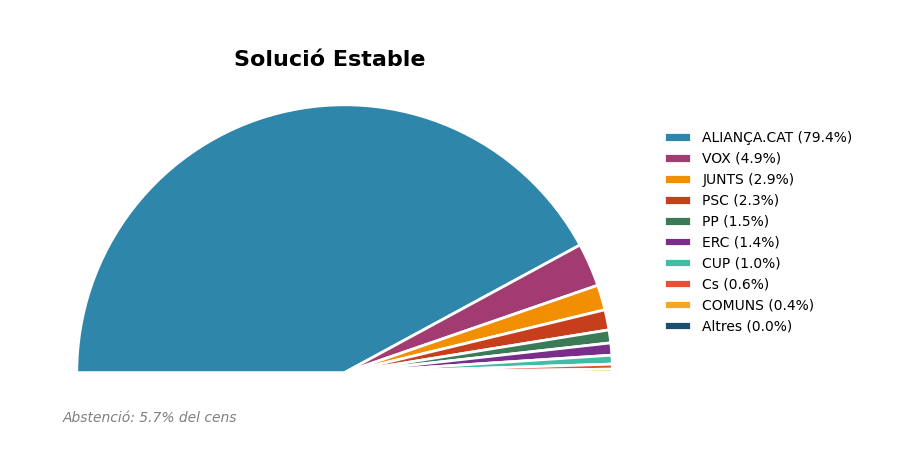

In [11]:
print(mc.get_steady_state())
mc.plot_steady_state()

### Temps per arribar a solució estacionària

Fem una simulació de l'evolució de la matriu de transició a partir de l'estat incial (any 1980). Amb aquesta simulació veiem en quantes eleccions arriba a la solució estàcionaria que haviem calculat anteriorment i fem una aproximació per calcular els anys total (num_eleccions * 4)

In [12]:
pi = mc.get_steady_state().values
p0 = df.loc[1980].values
epsilon = 1e-5
p = p0.copy()
t = 0
historia = [p.copy()]

P = mc.transition_matrix.values

# Afegeix un màxim de passos per seguretat
MAX_PASSOS = 10000

while t < MAX_PASSOS:
    p_nou = P @ p
    diferencia = np.max(np.abs(p_nou - pi))
    historia.append(p_nou.copy())
    t += 1
    if diferencia < epsilon:
        break
    p = p_nou

if t == MAX_PASSOS:
    print("No ha convergit en el màxim de passos!")

print(f"Convergència assolida en {t} eleccions (~{t*4} anys)")
print(f"Distribució estacionària π:")
for partit, prob in zip(list(df.columns), pi):
    print(f"  {partit}: {prob:.3f}")

La matriu és reductible. Calculant comportament a llarg termini...
No ha convergit en el màxim de passos!
Convergència assolida en 10000 eleccions (~40000 anys)
Distribució estacionària π:
  PSC: 0.023
  JUNTS: 0.029
  ERC: 0.014
  PP: 0.015
  VOX: 0.049
  COMUNS: 0.004
  CUP: 0.010
  ALIANÇA.CAT: 0.794
  Altres: 0.000
  Cs: 0.006
  Abstenció: 0.057


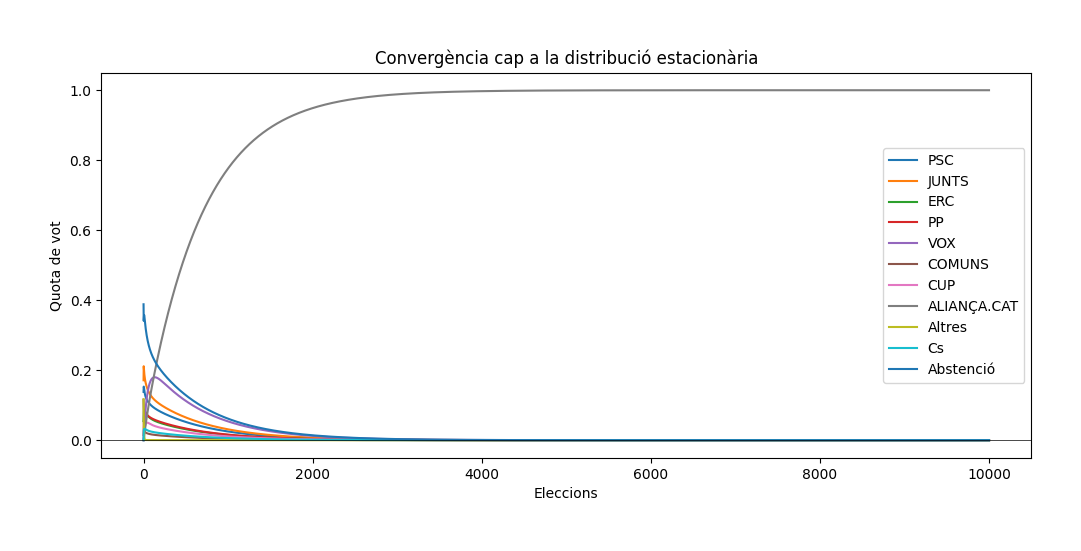

In [13]:
import matplotlib.pyplot as plt

historia = np.array(historia)

plt.figure(figsize=(12, 5))
for j, partit in enumerate(list(df.columns)):
    plt.plot(historia[:, j], label=partit)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlabel("Eleccions")
plt.ylabel("Quota de vot")
plt.title("Convergència cap a la distribució estacionària")
plt.legend()
plt.show()

### Costumer lifetime value

Busquem el número d'eleccions consecutives que de mitjana un votant votaria al mateix partit: $\frac{1}{1-retenció}$

In [14]:
retencio = mc.transition_matrix.values.diagonal()
print("Retenció (probabilitat de mantenir votants):")

clv = 1 / (1 - retencio)

print("CLV (Customer Lifetime Value) estimat per cada partit:")
for partit, clv_value in zip(list(df.columns), clv):
    print(f"  {partit}: {round(clv_value, 2)} ~ {round(clv_value, 0)} eleccions")

Retenció (probabilitat de mantenir votants):
CLV (Customer Lifetime Value) estimat per cada partit:
  PSC: 4.56 ~ 5.0 eleccions
  JUNTS: 2.46 ~ 2.0 eleccions
  ERC: 3.36 ~ 3.0 eleccions
  PP: 5.57 ~ 6.0 eleccions
  VOX: 62.07 ~ 62.0 eleccions
  COMUNS: 4.1 ~ 4.0 eleccions
  CUP: 16.55 ~ 17.0 eleccions
  ALIANÇA.CAT: inf ~ inf eleccions
  Altres: 3.96 ~ 4.0 eleccions
  Cs: 1.66 ~ 2.0 eleccions
  Abstenció: 2.69 ~ 3.0 eleccions


C:\Users\laiaq\AppData\Local\Temp\ipykernel_19668\2549160280.py:4: RuntimeWarning: divide by zero encountered in divide
  clv = 1 / (1 - retencio)
